In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez, firwin, lfilter


# Chapter 2 & 3 Common Helper Functions

def opt_filter(filtorder: int, N: int):
    """Optimal lowpass prototype filter design for Pseudo-QMF bank."""
    stopedge = 1.0 / N
    passedge = 1.0 / (4 * N)
    tol = 1e-6
    step = 0.1 * passedge
    way = -1
    pcost = 10.0
    flag = False

    while not flag:
        p = remez(filtorder + 1, [0, passedge, stopedge, 1.0], [1, 0], weight=[5, 1], fs=2.0)
        P = np.fft.fft(p, 4096)
        OptRange = int(np.floor(2048 / N))
        phi = np.zeros(OptRange)
        for k in range(1, OptRange + 1):
            phi[k - 1] = np.abs(P[OptRange - k + 1])**2 + np.abs(P[k - 1])**2
        tcost = np.max(np.abs(phi - 1.0))
        if tcost > pcost:
            step /= 2.0
            way = -way
        if np.abs(pcost - tcost) < tol:
            flag = True
        pcost = tcost
        passedge += way * step
    return p, passedge

def make_bank(p: np.ndarray, N: int):
    """Cosine-modulated analysis and synthesis filter banks (Eq. 2.35)."""
    L = len(p)
    H = np.zeros((N, L))
    n = np.arange(L)
    for i in range(N):
        H[i, :] = 2 * p * np.cos((np.pi / N) * (i + 0.5) * (n - (L - 1) / 2.0) + ((-1)**i) * (np.pi / 4.0))
    F = np.fliplr(H)
    return H, F

def FreqResp(H: np.ndarray, DFTpoint: int = 4096):
    """Computes frequency response over [0, pi] or [0, 2pi]."""
    if H.ndim == 1:
        H = H.reshape(1, -1)
    N, L = H.shape
    Hz = np.zeros((N, DFTpoint), dtype=complex)
    for k in range(N):
        Hz[k, :] = np.fft.fft(H[k, :], 2 * DFTpoint)[:DFTpoint]
    w = np.linspace(0, np.pi, DFTpoint)
    return Hz.squeeze(), w

def PSDecimation(X: np.ndarray, DFTpoint: int, D: int):
    """Python translation of PSDecimation.m (Power Spectrum Decimation)."""
    delta_w = 2 * np.pi / DFTpoint
    XD = np.zeros((D, DFTpoint))

    for k in range(D):
        N_shift = int(np.round((2 * np.pi * k / D) / delta_w))
        x = X.copy()
        if N_shift > 0:
            x = np.roll(x, N_shift)
        XD[k, :] = x

    Npoint = int(np.round(DFTpoint / D))
    Npoint = (Npoint // 4) * 4
    XD_scaled = XD[:, :Npoint] / D
    xd = np.sum(XD_scaled, axis=0)

    delta_w_out = 2 * np.pi / Npoint
    w = np.arange(Npoint) * delta_w_out
    return xd, w, XD_scaled

def DCTmatrix_TypeIV(N: int):
    """Python translation of DCTmatrix_TypeIV.m (Type-IV DCT Matrix)."""
    n = np.arange(N).reshape(-1, 1)
    C = np.zeros((N, N))
    for k in range(N):
        C[:, k] = np.sqrt(2.0 / N) * np.cos((np.pi / N) * (k + 0.5) * (n + 0.5)).squeeze()
    return C

def AmpResp(h: np.ndarray, FreqPoint: int = 4096, FreqRange: int = 1, ShiftFreq: float = 0.0):
    """Python translation of AmpResp.m (Amplitude Response of Symmetric FIR)."""
    h = h.flatten()
    L = len(h)

    if FreqRange == 1:
        w = np.arange(FreqPoint) * 2 * np.pi / FreqPoint
    elif FreqRange == 2:
        FP_half = FreqPoint // 2
        w = np.arange(-FP_half + 1, FP_half) * np.pi / FP_half

    if L % 2 == 1: 
        alpha = (L - 1) // 2
        a = np.concatenate(([h[alpha]], 2 * h[alpha - 1::-1]))
        n = np.arange(alpha + 1)
        Hr = np.cos(np.outer(w + ShiftFreq, n)) @ a
    else: 
        alpha = L // 2
        b = 2 * h[alpha - 1::-1]
        n = np.arange(1, alpha + 1) - 0.5
        Hr = np.cos(np.outer(w + ShiftFreq, n)) @ b

    theta = -((L - 1) / 2.0) * w
    return Hr, w, theta

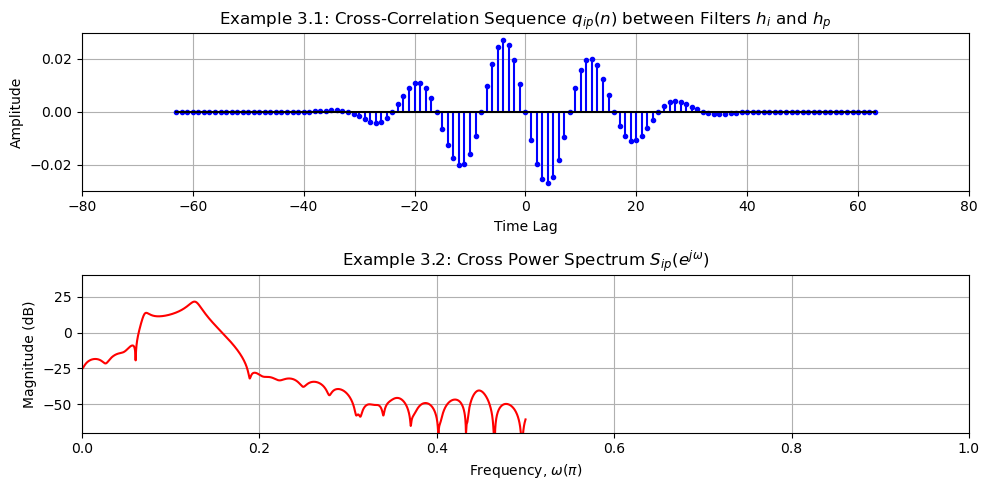

In [4]:

# Example 3.1 & 3.2 

N = 8; K = 4; L = 2 * K * N
hopt, passedge = opt_filter(L - 1, N)
H, F = make_bank(hopt, N)


a = np.array([1.00, -1.32, 0.86, -0.45, -0.62, 0.98, -0.65, 0.54,
              0.37, -0.51, 0.37, -0.40, 0.06, -0.15, 0.12, 0.20])

np.random.seed(42)
wgn = np.random.randn(4 * 80000)
un = lfilter([1.0], a, wgn)
un = un / np.std(un)


k = 0; i = k; p = k + 1
h_i = H[i, :]; h_p = H[p, :]
q_ip = np.correlate(h_i, h_p, mode='full')


plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(np.arange(-L + 1, L), q_ip, linefmt='b-', markerfmt='b.', basefmt='k-')
plt.title('Example 3.1: Cross-Correlation Sequence $q_{ip}(n)$ between Filters $h_i$ and $h_p$')
plt.ylabel('Amplitude'); plt.xlabel('Time Lag')
plt.xlim([-80, 80]); plt.grid(True)

DFTpoint = 4096
A_resp, w = FreqResp(a, DFTpoint)
Q_ip, w = FreqResp(q_ip, DFTpoint)
H_i_resp, w = FreqResp(h_i, DFTpoint)
H_p_resp, w = FreqResp(h_p, DFTpoint)

InputSpectrum = 1.0 / (np.abs(A_resp)**2)
CrossSpectrum = Q_ip * InputSpectrum

plt.subplot(2, 1, 2)
plt.plot(w[:2049] / np.pi, 10 * np.log10(np.abs(CrossSpectrum[:2049]) + 1e-12), 'r')
plt.title('Example 3.2: Cross Power Spectrum $S_{ip}(e^{j\omega})$')
plt.xlabel(r'Frequency, $\omega (\pi)$'); plt.ylabel('Magnitude (dB)')
plt.xlim([0, 1]); plt.ylim([-70, 40]); plt.grid(True)
plt.tight_layout()
plt.show()

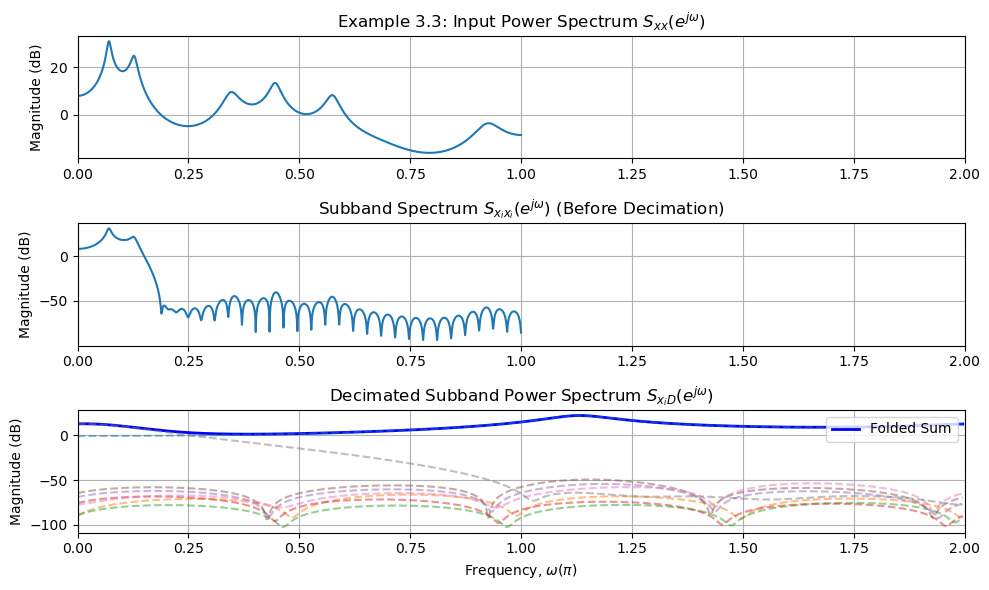

In [5]:

# Example 3.3 Execution

k = 0; i = k; p = k
h_i_3 = H[i, :]; h_p_3 = H[p, :]
q_ip_3 = np.correlate(h_i_3, h_p_3, mode='full')

Q_ip_3, w = FreqResp(q_ip_3, DFTpoint)
SubbandSpectrum = np.abs(Q_ip_3) * InputSpectrum
SubbandSpectrum_D, w_D, XD = PSDecimation(SubbandSpectrum, DFTpoint, N)

plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(w / np.pi, 10 * np.log10(InputSpectrum + 1e-12))
plt.title('Example 3.3: Input Power Spectrum $S_{xx}(e^{j\omega})$')
plt.ylabel('Magnitude (dB)'); plt.xlim([0, 2]); plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(w / np.pi, 10 * np.log10(np.abs(SubbandSpectrum) + 1e-12))
plt.title('Subband Spectrum $S_{x_i x_i}(e^{j\omega})$ (Before Decimation)')
plt.ylabel('Magnitude (dB)'); plt.xlim([0, 2]); plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(w_D / np.pi, 10 * np.log10(SubbandSpectrum_D + 1e-12), 'b', linewidth=2.0, label='Folded Sum')
for d in range(N):
    plt.plot(w_D / np.pi, 10 * np.log10(XD[d, :] + 1e-12), '--', alpha=0.5)
plt.title('Decimated Subband Power Spectrum $S_{x_i D}(e^{j\omega})$')
plt.xlabel(r'Frequency, $\omega (\pi)$'); plt.ylabel('Magnitude (dB)')
plt.xlim([0, 2]); plt.grid(True); plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

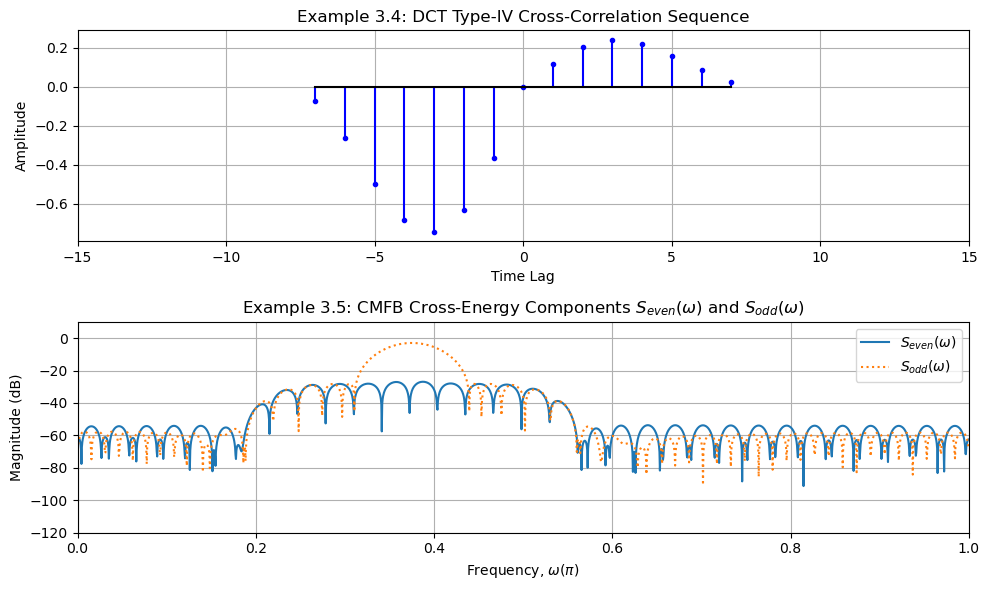

In [6]:

# Example 3.4 & 3.5 Execution

N_dct = 8
H_dct = DCTmatrix_TypeIV(N_dct)
q_ip_dct = np.correlate(H_dct[0, :], H_dct[1, :], mode='full')

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.stem(np.arange(-N_dct + 1, N_dct), q_ip_dct, linefmt='b-', markerfmt='b.', basefmt='k-')
plt.title('Example 3.4: DCT Type-IV Cross-Correlation Sequence')
plt.xlabel('Time Lag'); plt.ylabel('Amplitude')
plt.xlim([-15, 15]); plt.grid(True)


i = 2; p = 3
ShiftFreq_i_R = -(np.pi / N) * (i + 0.5)
Ui, w_amp, _ = AmpResp(hopt, DFTpoint, 2, ShiftFreq_i_R)
ShiftFreq_i_L = (np.pi / N) * (i + 0.5)
Vi, w_amp, _ = AmpResp(hopt, DFTpoint, 2, ShiftFreq_i_L)

ShiftFreq_p_R = -(np.pi / N) * (p + 0.5)
Up, w_amp, _ = AmpResp(hopt, DFTpoint, 2, ShiftFreq_p_R)
ShiftFreq_p_L = (np.pi / N) * (p + 0.5)
Vp, w_amp, _ = AmpResp(hopt, DFTpoint, 2, ShiftFreq_p_L)

if np.abs(i - p) % 2 != 0:
    S_odd = ((-1)**i) * (Ui * Up - Vi * Vp)
    S_even = Ui * Vp + Vi * Up
else:
    S_odd = ((-1)**i) * (Ui * Vp - Vi * Up)
    S_even = Ui * Up + Vi * Vp

plt.subplot(2, 1, 2)
plt.plot(w_amp[len(w_amp)//2:] / np.pi, 10 * np.log10(np.abs(S_even[len(S_even)//2:]) + 1e-12), label=r'$S_{even}(\omega)$')
plt.plot(w_amp[len(w_amp)//2:] / np.pi, 10 * np.log10(np.abs(S_odd[len(S_odd)//2:]) + 1e-12), ':', label=r'$S_{odd}(\omega)$')
plt.title(r'Example 3.5: CMFB Cross-Energy Components $S_{even}(\omega)$ and $S_{odd}(\omega)$')
plt.xlabel(r'Frequency, $\omega (\pi)$'); plt.ylabel('Magnitude (dB)')
plt.xlim([0, 1]); plt.ylim([-120, 10]); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()